# Transformation(**optional**)

In case you want to transform images to our training set

New images folder: ../data/data_transformation/start
Reference images folder: ../data/data_transformation/reference_style
Output folder: ../data/data_transformation/end
Processed 5851.jpg and applied settings


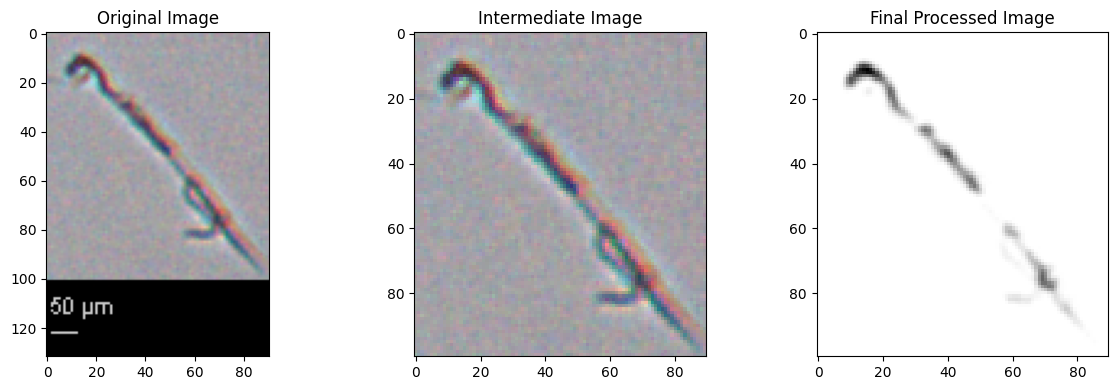

Processed 6164.jpg and applied settings


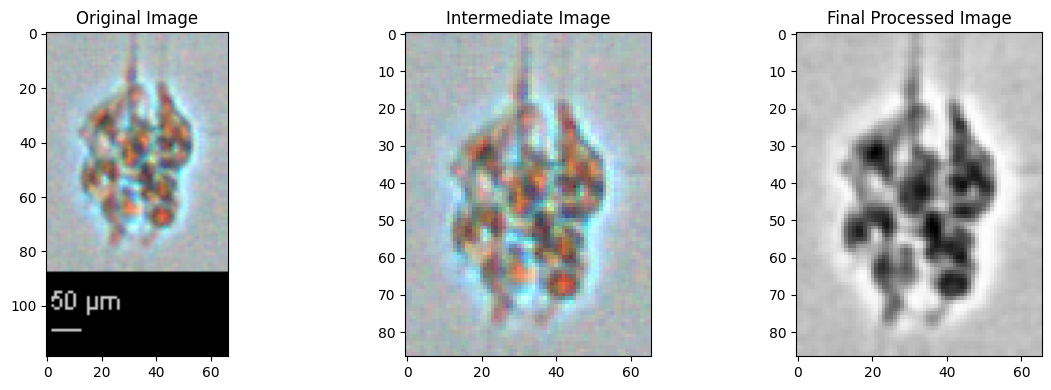

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

new_images_folder = '../data/data_transformation/start'
output_folder = '../data/data_transformation/end'
reference_style_folder = '../data/data_transformation/reference_style'
legacy_reference_folder = '../data/data_transformation/middle'

os.makedirs(new_images_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)
os.makedirs(reference_style_folder, exist_ok=True)
os.makedirs(legacy_reference_folder, exist_ok=True)

if os.listdir(reference_style_folder):
    reference_folder = reference_style_folder
elif os.listdir(legacy_reference_folder):
    reference_folder = legacy_reference_folder
else:
    reference_folder = reference_style_folder
print(f'New images folder: {new_images_folder}')
print(f'Reference images folder: {reference_folder}')
print(f'Output folder: {output_folder}')

# Adjustable Parameters
noise_std = 0
kernel_size = 3
threshold = 0.2

def apply_settings_to_image(image, brightness, contrast):
    adjusted_image = cv2.convertScaleAbs(image, alpha=contrast, beta=brightness)
    return adjusted_image

def calculate_average_grayscale_stats(image_folder):
    image_files = [name for name in os.listdir(image_folder) if name.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
    total_intensity = 0
    total_contrast = 0
    total_images = 0

    for image_file in image_files:
        image_path = os.path.join(image_folder, image_file)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is not None:
            total_intensity += np.mean(image)
            total_contrast += np.std(image)
            total_images += 1

    if total_images == 0:
        raise FileNotFoundError(
            f'No readable reference images found in {image_folder}. Put one or more example transformed images in ../data/data_transformation/reference_style first. Older projects may still use ../data/data_transformation/middle.'
        )

    average_intensity = total_intensity / total_images
    average_contrast = total_contrast / total_images
    return average_intensity, average_contrast

def find_continuous_indices(arr, threshold_value, continuous_count):
    above_threshold = arr > threshold_value
    indices = np.where(above_threshold)[0]
    continuous_indices = []
    temp = []

    for idx in indices:
        if len(temp) == 0 or idx == temp[-1] + 1:
            temp.append(idx)
        else:
            temp = [idx]

        if len(temp) >= continuous_count:
            continuous_indices.extend(temp)

    return continuous_indices

def find_cropping_indices(indices_list, continuous_count):
    cropping_indices = []
    for i in range(len(indices_list) - continuous_count + 1):
        cropping_indices.append(indices_list[i:i+continuous_count])
    return cropping_indices

def remove_black_bars(image):
    threshold = 0.2
    row_sum = np.sum(image != 0, axis=1)
    col_sum = np.sum(image != 0, axis=0)

    continuous_count = 2

    bottom_cropping_indices = find_cropping_indices(find_continuous_indices(row_sum[::-1], threshold * image.shape[1], continuous_count), continuous_count)
    right_cropping_indices = find_cropping_indices(find_continuous_indices(col_sum[::-1], threshold * image.shape[0], continuous_count), continuous_count)

    max_bottom = 0
    max_right = 0

    for bottom_indices in bottom_cropping_indices:
        for right_indices in right_cropping_indices:
            bottom = image.shape[0] - bottom_indices[-1] if len(bottom_indices) > 0 else image.shape[0]
            right = image.shape[1] - right_indices[-1] if len(right_indices) > 0 else image.shape[1]

            if bottom > max_bottom:
                max_bottom = bottom
            if right > max_right:
                max_right = right

    cropped_image = image[:max_bottom, :max_right]
    return cropped_image

original_avg_brightness, original_avg_contrast = calculate_average_grayscale_stats(reference_folder)

new_image_files = [name for name in os.listdir(new_images_folder) if name.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]
if not new_image_files:
    raise FileNotFoundError(
        f'No input images found in {new_images_folder}. Put your new raw images there and rerun the notebook cell.'
    )

for new_file in new_image_files:
    new_image_path = os.path.join(new_images_folder, new_file)
    new_color_image = cv2.imread(new_image_path)

    if new_color_image is None:
        print(f'Skipped {new_file} due to missing image')
        continue

    cleaned_image = remove_black_bars(new_color_image)
    brightness_factor = original_avg_brightness / np.mean(cleaned_image)
    contrast_factor = original_avg_contrast / np.std(cleaned_image)
    average_new_intensity = np.mean(cleaned_image)
    scaling_factor = original_avg_brightness / average_new_intensity
    adjusted_image = np.clip(cleaned_image * scaling_factor, 0, 255).astype(np.uint8)
    adjusted_image = apply_settings_to_image(adjusted_image, brightness_factor, contrast_factor)
    noisy_image = adjusted_image + np.random.normal(0, noise_std, adjusted_image.shape).astype(np.uint8)
    blurred_image = cv2.GaussianBlur(noisy_image, (kernel_size, kernel_size), 0)
    grayscale_image = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2GRAY)

    output_path = os.path.join(output_folder, new_file)
    cv2.imwrite(output_path, grayscale_image)
    print(f'Processed {new_file} and applied settings')

    plt.figure(figsize=(12, 4))
    plt.subplot(131)
    plt.title('Original Image')
    plt.imshow(new_color_image)

    plt.subplot(132)
    plt.title('Intermediate Image')
    plt.imshow(cleaned_image)

    plt.subplot(133)
    plt.title('Final Processed Image')
    plt.imshow(grayscale_image, cmap='gray')

    plt.tight_layout()
    plt.show()
